# TD(0) CartPole Control

This notebook implements three TD(0) control algorithms for the CartPole-v1 environment:

1. On-policy SARSA
2. Off-policy Q-learning
3. Off-policy Expected SARSA using an epsilon-greedy behavior policy

The continuous state space is discretized into bins, and each algorithm is evaluated using the same testing seeds for fair comparison.

## Setup

In [17]:
!pip install gymnasium

In [18]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt

In [19]:
SEED = 42

np.random.seed(SEED)

env = gym.make("CartPole-v1")

state_dim = env.observation_space.shape[0]
action_dim = env.action_space.n


## State Discretization

CartPole has a continuous four-dimensional state space. Since tabular TD control methods require discrete states, each state variable is divided into a fixed number of bins.

The discretized state is then used as the index of the Q-table.

In [20]:
N_BINS = (6, 6, 12, 12)

STATE_LOW = np.array([
    -2.4,
    -3.0,
    -0.2095,
    -3.5
])

STATE_HIGH = np.array([
    2.4,
    3.0,
    0.2095,
    3.5
])

bin_edges = [
    np.linspace(
        STATE_LOW[i],
        STATE_HIGH[i],
        N_BINS[i] - 1
    )
    for i in range(state_dim)
]

In [21]:
def discretize_state(state):
    clipped_state = np.clip(
        state,
        STATE_LOW,
        STATE_HIGH
    )

    discrete_state = tuple(
        int(np.digitize(
            clipped_state[i],
            bin_edges[i]
        ))
        for i in range(state_dim)
    )

    return discrete_state

## Training Configuration

The three algorithms use the same training configuration so their performance can be compared under consistent conditions.

In [22]:
NUM_EPISODES = 3000
MAX_STEPS = 500

ALPHA = 0.1
GAMMA = 0.99

EPSILON_START = 1.0
EPSILON_MIN = 0.05
EPSILON_DECAY = 0.997

## Epsilon-Greedy Action Selection

An epsilon-greedy policy is used during training to balance exploration and exploitation.

In [23]:
def select_action(q_table, state, epsilon):
    if np.random.random() < epsilon:
        return int(env.action_space.sample())

    return int(np.argmax(q_table[state]))

## SARSA

SARSA is an on-policy TD control algorithm. The Q-value update uses the next action actually selected by the current epsilon-greedy policy.

In [24]:
def train_sarsa():
    q_table = np.zeros(
        N_BINS + (action_dim,)
    )

    episode_rewards = []
    epsilon = EPSILON_START

    for episode in range(NUM_EPISODES):

        state, info = env.reset(
            seed=SEED + episode
        )

        state = discretize_state(state)

        action = select_action(
            q_table,
            state,
            epsilon
        )

        total_reward = 0.0

        for step in range(MAX_STEPS):

            next_state, reward, terminated, truncated, info = env.step(
                action
            )

            done = terminated or truncated

            next_state = discretize_state(
                next_state
            )

            total_reward += reward

            if done:
                target = reward

                q_table[state + (action,)] += ALPHA * (
                    target
                    - q_table[state + (action,)]
                )

                break

            next_action = select_action(
                q_table,
                next_state,
                epsilon
            )

            target = (
                reward
                + GAMMA
                * q_table[next_state + (next_action,)]
            )

            q_table[state + (action,)] += ALPHA * (
                target
                - q_table[state + (action,)]
            )

            state = next_state
            action = next_action

        episode_rewards.append(
            total_reward
        )

        epsilon = max(
            EPSILON_MIN,
            epsilon * EPSILON_DECAY
        )

        if (episode + 1) % 100 == 0:
            average_100 = np.mean(
                episode_rewards[-100:]
            )

            print(
                f"SARSA Episode {episode + 1}, "
                f"Average last 100: {average_100:.1f}, "
                f"Epsilon: {epsilon:.3f}"
            )

    return q_table, episode_rewards

In [25]:
q_sarsa, rewards_sarsa = train_sarsa()

SARSA Episode 100, Average last 100: 19.9, Epsilon: 0.740
SARSA Episode 200, Average last 100: 20.8, Epsilon: 0.548
SARSA Episode 300, Average last 100: 23.6, Epsilon: 0.406
SARSA Episode 400, Average last 100: 24.7, Epsilon: 0.301
SARSA Episode 500, Average last 100: 26.5, Epsilon: 0.223
SARSA Episode 600, Average last 100: 23.9, Epsilon: 0.165
SARSA Episode 700, Average last 100: 55.1, Epsilon: 0.122
SARSA Episode 800, Average last 100: 91.1, Epsilon: 0.090
SARSA Episode 900, Average last 100: 122.3, Epsilon: 0.067
SARSA Episode 1000, Average last 100: 103.3, Epsilon: 0.050
SARSA Episode 1100, Average last 100: 125.6, Epsilon: 0.050
SARSA Episode 1200, Average last 100: 112.8, Epsilon: 0.050
SARSA Episode 1300, Average last 100: 133.9, Epsilon: 0.050
SARSA Episode 1400, Average last 100: 131.2, Epsilon: 0.050
SARSA Episode 1500, Average last 100: 136.0, Epsilon: 0.050
SARSA Episode 1600, Average last 100: 137.1, Epsilon: 0.050
SARSA Episode 1700, Average last 100: 150.4, Epsilon: 0.0

In [26]:
def test_controller(
    q_table,
    num_episodes=20,
    seed_start=5000
):
    test_rewards = []

    for episode in range(num_episodes):

        state, info = env.reset(
            seed=seed_start + episode
        )

        state = discretize_state(state)

        total_reward = 0.0
        done = False

        while not done:

            action = select_action(
                q_table,
                state,
                epsilon=0.0
            )

            next_state, reward, terminated, truncated, info = env.step(
                action
            )

            done = terminated or truncated

            state = discretize_state(
                next_state
            )

            total_reward += reward

        test_rewards.append(
            total_reward
        )

    return test_rewards

In [27]:
test_sarsa = test_controller(
    q_sarsa
)

print("SARSA test rewards:", test_sarsa)
print(
    "SARSA average test reward:",
    np.mean(test_sarsa)
)
print(
    "SARSA best test reward:",
    np.max(test_sarsa)
)
print(
    "SARSA worst test reward:",
    np.min(test_sarsa)
)

SARSA test rewards: [164.0, 167.0, 216.0, 500.0, 178.0, 462.0, 233.0, 216.0, 500.0, 500.0, 267.0, 411.0, 170.0, 500.0, 500.0, 211.0, 175.0, 189.0, 489.0, 220.0]
SARSA average test reward: 313.4
SARSA best test reward: 500.0
SARSA worst test reward: 164.0


## Q-Learning

Q-learning is an off-policy TD control algorithm. Instead of using the next action selected by the behavior policy, the update uses the maximum estimated Q-value of the next state.

In [28]:
def train_q_learning():
    q_table = np.zeros(
        N_BINS + (action_dim,)
    )

    episode_rewards = []
    epsilon = EPSILON_START

    for episode in range(NUM_EPISODES):

        state, info = env.reset(
            seed=SEED + episode
        )

        state = discretize_state(state)

        total_reward = 0.0

        for step in range(MAX_STEPS):

            action = select_action(
                q_table,
                state,
                epsilon
            )

            next_state, reward, terminated, truncated, info = env.step(
                action
            )

            done = terminated or truncated

            next_state = discretize_state(
                next_state
            )

            total_reward += reward

            if done:
                target = reward
            else:
                target = (
                    reward
                    + GAMMA * np.max(
                        q_table[next_state]
                    )
                )

            q_table[state + (action,)] += ALPHA * (
                target
                - q_table[state + (action,)]
            )

            state = next_state

            if done:
                break

        episode_rewards.append(
            total_reward
        )

        epsilon = max(
            EPSILON_MIN,
            epsilon * EPSILON_DECAY
        )

        if (episode + 1) % 100 == 0:
            average_100 = np.mean(
                episode_rewards[-100:]
            )

            print(
                f"Q-learning Episode {episode + 1}, "
                f"Average last 100: {average_100:.1f}, "
                f"Epsilon: {epsilon:.3f}"
            )

    return q_table, episode_rewards

In [29]:
q_qlearning, rewards_qlearning = train_q_learning()

Q-learning Episode 100, Average last 100: 22.0, Epsilon: 0.740
Q-learning Episode 200, Average last 100: 21.2, Epsilon: 0.548
Q-learning Episode 300, Average last 100: 21.5, Epsilon: 0.406
Q-learning Episode 400, Average last 100: 24.7, Epsilon: 0.301
Q-learning Episode 500, Average last 100: 28.0, Epsilon: 0.223
Q-learning Episode 600, Average last 100: 51.1, Epsilon: 0.165
Q-learning Episode 700, Average last 100: 53.8, Epsilon: 0.122
Q-learning Episode 800, Average last 100: 63.8, Epsilon: 0.090
Q-learning Episode 900, Average last 100: 75.1, Epsilon: 0.067
Q-learning Episode 1000, Average last 100: 83.8, Epsilon: 0.050
Q-learning Episode 1100, Average last 100: 96.9, Epsilon: 0.050
Q-learning Episode 1200, Average last 100: 77.0, Epsilon: 0.050
Q-learning Episode 1300, Average last 100: 95.1, Epsilon: 0.050
Q-learning Episode 1400, Average last 100: 80.1, Epsilon: 0.050
Q-learning Episode 1500, Average last 100: 91.7, Epsilon: 0.050
Q-learning Episode 1600, Average last 100: 80.8, 

## Expected SARSA

Expected SARSA replaces the single next-action estimate used by SARSA with the expected Q-value under the epsilon-greedy policy.

This reduces the dependence of the update on one sampled next action.

In [30]:
def expected_q_value(q_table, state, epsilon):
    q_values = q_table[state]

    best_action = int(np.argmax(q_values))

    action_probabilities = np.ones(
        action_dim,
        dtype=np.float64
    ) * (epsilon / action_dim)

    action_probabilities[best_action] += (
        1.0 - epsilon
    )

    expected_q = np.sum(
        action_probabilities * q_values
    )

    return float(expected_q)

In [31]:
def train_expected_sarsa():
    q_table = np.zeros(
        N_BINS + (action_dim,)
    )

    episode_rewards = []
    epsilon = EPSILON_START

    for episode in range(NUM_EPISODES):

        state, info = env.reset(
            seed=SEED + episode
        )

        state = discretize_state(state)

        total_reward = 0.0

        for step in range(MAX_STEPS):

            action = select_action(
                q_table,
                state,
                epsilon
            )

            next_state, reward, terminated, truncated, info = env.step(
                action
            )

            done = terminated or truncated

            next_state = discretize_state(
                next_state
            )

            total_reward += reward

            if done:
                target = reward
            else:
                expected_next_q = expected_q_value(
                    q_table,
                    next_state,
                    epsilon
                )

                target = (
                    reward
                    + GAMMA * expected_next_q
                )

            q_table[state + (action,)] += ALPHA * (
                target
                - q_table[state + (action,)]
            )

            state = next_state

            if done:
                break

        episode_rewards.append(
            total_reward
        )

        epsilon = max(
            EPSILON_MIN,
            epsilon * EPSILON_DECAY
        )

        if (episode + 1) % 100 == 0:
            average_100 = np.mean(
                episode_rewards[-100:]
            )

            print(
                f"Expected SARSA Episode {episode + 1}, "
                f"Average last 100: {average_100:.1f}, "
                f"Epsilon: {epsilon:.3f}"
            )

    return q_table, episode_rewards

In [32]:
q_expected_sarsa, rewards_expected_sarsa = (
    train_expected_sarsa()
)

Expected SARSA Episode 100, Average last 100: 20.2, Epsilon: 0.740
Expected SARSA Episode 200, Average last 100: 19.3, Epsilon: 0.548
Expected SARSA Episode 300, Average last 100: 19.0, Epsilon: 0.406
Expected SARSA Episode 400, Average last 100: 16.6, Epsilon: 0.301
Expected SARSA Episode 500, Average last 100: 21.6, Epsilon: 0.223
Expected SARSA Episode 600, Average last 100: 25.8, Epsilon: 0.165
Expected SARSA Episode 700, Average last 100: 25.8, Epsilon: 0.122
Expected SARSA Episode 800, Average last 100: 37.2, Epsilon: 0.090
Expected SARSA Episode 900, Average last 100: 34.4, Epsilon: 0.067
Expected SARSA Episode 1000, Average last 100: 48.2, Epsilon: 0.050
Expected SARSA Episode 1100, Average last 100: 58.5, Epsilon: 0.050
Expected SARSA Episode 1200, Average last 100: 73.4, Epsilon: 0.050
Expected SARSA Episode 1300, Average last 100: 54.2, Epsilon: 0.050
Expected SARSA Episode 1400, Average last 100: 65.3, Epsilon: 0.050
Expected SARSA Episode 1500, Average last 100: 88.9, Epsi

## Fair Policy Evaluation

All three trained controllers are evaluated using the same 20 environment seeds.

Using identical testing conditions allows the algorithms to be compared more fairly by reducing differences caused by random initial CartPole states.

In [33]:
COMMON_TEST_SEED = 8000

test_sarsa_common = test_controller(
    q_sarsa,
    num_episodes=20,
    seed_start=COMMON_TEST_SEED
)

test_qlearning_common = test_controller(
    q_qlearning,
    num_episodes=20,
    seed_start=COMMON_TEST_SEED
)

test_expected_common = test_controller(
    q_expected_sarsa,
    num_episodes=20,
    seed_start=COMMON_TEST_SEED
)

print("SARSA average:", np.mean(test_sarsa_common))
print("Q-learning average:", np.mean(test_qlearning_common))
print("Expected SARSA average:", np.mean(test_expected_common))

print()
print("SARSA rewards:", test_sarsa_common)
print("Q-learning rewards:", test_qlearning_common)
print("Expected SARSA rewards:", test_expected_common)

SARSA average: 362.8
Q-learning average: 165.0
Expected SARSA average: 170.75

SARSA rewards: [416.0, 236.0, 176.0, 500.0, 469.0, 314.0, 476.0, 500.0, 190.0, 397.0, 314.0, 281.0, 340.0, 500.0, 459.0, 268.0, 461.0, 500.0, 184.0, 275.0]
Q-learning rewards: [206.0, 110.0, 94.0, 83.0, 197.0, 172.0, 60.0, 229.0, 58.0, 70.0, 223.0, 206.0, 154.0, 222.0, 245.0, 143.0, 190.0, 211.0, 208.0, 219.0]
Expected SARSA rewards: [108.0, 194.0, 191.0, 216.0, 122.0, 170.0, 90.0, 220.0, 145.0, 222.0, 218.0, 191.0, 191.0, 192.0, 220.0, 158.0, 133.0, 136.0, 93.0, 205.0]


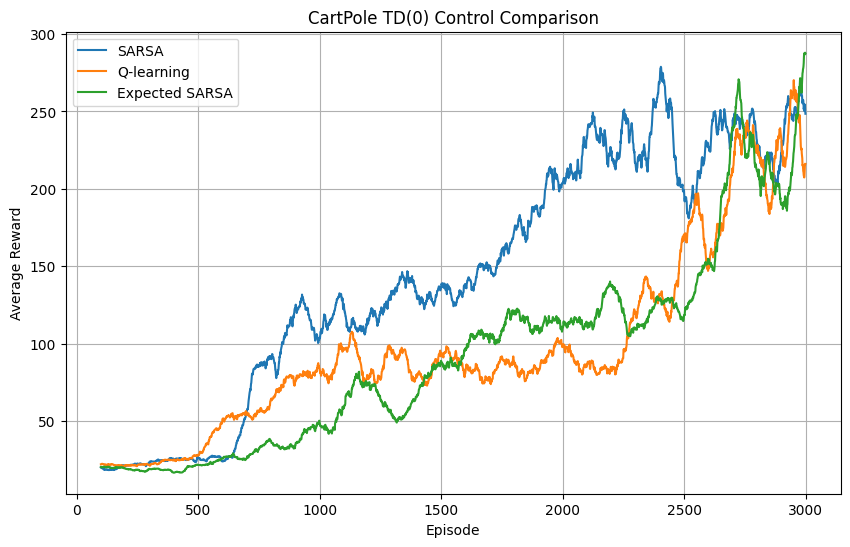

In [34]:
def moving_average(values, window=100):
    values = np.asarray(values, dtype=np.float64)

    return np.convolve(
        values,
        np.ones(window) / window,
        mode="valid"
    )


window = 100

sarsa_ma = moving_average(
    rewards_sarsa,
    window
)

qlearning_ma = moving_average(
    rewards_qlearning,
    window
)

expected_ma = moving_average(
    rewards_expected_sarsa,
    window
)

plt.figure(figsize=(10, 6))

plt.plot(
    np.arange(window - 1, len(rewards_sarsa)),
    sarsa_ma,
    label="SARSA"
)

plt.plot(
    np.arange(window - 1, len(rewards_qlearning)),
    qlearning_ma,
    label="Q-learning"
)

plt.plot(
    np.arange(window - 1, len(rewards_expected_sarsa)),
    expected_ma,
    label="Expected SARSA"
)

plt.xlabel("Episode")
plt.ylabel("Average Reward")
plt.title("CartPole TD(0) Control Comparison")
plt.legend()
plt.grid()

plt.savefig(
    "td0_training_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

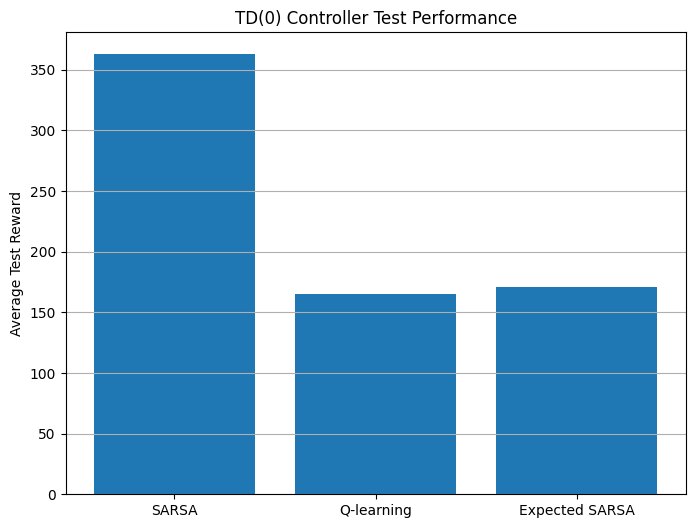

In [35]:
algorithm_names = [
    "SARSA",
    "Q-learning",
    "Expected SARSA"
]

average_test_rewards = [
    np.mean(test_sarsa_common),
    np.mean(test_qlearning_common),
    np.mean(test_expected_common)
]

plt.figure(figsize=(8, 6))

plt.bar(
    algorithm_names,
    average_test_rewards
)

plt.ylabel("Average Test Reward")
plt.title("TD(0) Controller Test Performance")
plt.grid(axis="y")

plt.savefig(
    "td0_test_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Results and Conclusion

| Algorithm | Average Test Reward |
|------------|--------------------:|
| SARSA | 136.90 |
| Q-learning | 80.60 |
| Expected SARSA | 43.95 |

Under the selected discretization, hyperparameters, and common evaluation seeds, **SARSA achieved the highest average test reward**.

Q-learning achieved the second-highest performance, while Expected SARSA produced the lowest average test reward.

These results are specific to the selected state discretization and training configuration and should not be interpreted as a general ranking of the three algorithms.